In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import interp1d
from sklearn.cluster import KMeans
import matplotlib.patheffects as path_effects

## Basic principle
Given a folder name we can gather all pathways from these trials, as well as all histories. AN efficient way to do this is using a table that links to the pathways. This is what ```get_organised``` does. It returns the name of algorithm (trial = Microbial), (NEAT = NEAT), (Diff = Differential) and (RL_TRIAL = Reinforcmnt learning). The name of the experiment isunder "experiment". And finaly the file is stored relating to it. It will be a numpy file


Once you have gathered this you can move onto processing the numpy files. Something to be aware of is not all routes make it to the end, so the arrays are filled with (0,0) to pad out the non values. Make sure to remove these from the plotting. Then you can use the ```get_arrays``` function to loop through all the trials or given trials as a parameter to get all routes for that.

In [99]:
def get_organised(base_dir = 'data',target_file = 'file to find'):
    rows = []
    # Walk through all subdirectories
    for root, dirs, files in os.walk(base_dir):
        print(target_file)
        print(files)
        if target_file in str(files):
            #print("Y")
            parts = os.path.normpath(root).split(os.sep)
            #print("partds",parts)
            if len(parts) >= 3:
                grandparent = parts[-2]
                parent = parts[-1]
                file_path = os.path.join(root, target_file)
                rows.append((grandparent, parent, file_path))
    df = pd.DataFrame(rows, columns=['Algorithm', 'Experiment', 'File'])
    return df

#all_learning_routes=get_organised("DexGATracks","routes_over_time.npy") #all files 
all_end_routes=get_organised("DexGATracks","routes.npy") #all files 


routes.npy
[]
routes.npy
[]
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST12']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST8']
routes.npy
[]
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST6']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST0']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST10']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST3']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST4']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST9']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST1']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST7']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST5']
routes.npy
[]
routes.npy
['routes.npy']
partds ['DexGATracks', 'NEAT', 'ST2']
routes.npy
[]
routes

In [100]:
rlpath = get_organised("DexGATracks/RL/", "RLroutes.npy")

print(rlpath)

RLroutes.npy
['RLfitnesses.npy', 'RLroutes.npy']
partds ['DexGATracks', 'RL']
Empty DataFrame
Columns: [Algorithm, Experiment, File]
Index: []


In [101]:
rlpath =np.load("DexGATracks/RL/RLroutes.npy")

In [104]:
rl_pathsdf = pd.DataFrame(rlpath)

ValueError: Must pass 2-d input. shape=(20, 100, 2)

In [3]:
all_end_routes

,Algorithm,Experiment,File
0,NEAT,ST12,DexGATracks/NEAT/ST12/routes
1,NEAT,ST8,DexGATracks/NEAT/ST8/routes
2,NEAT,ST6,DexGATracks/NEAT/ST6/routes
3,NEAT,ST0,DexGATracks/NEAT/ST0/routes
4,NEAT,ST10,DexGATracks/NEAT/ST10/routes
5,NEAT,ST3,DexGATracks/NEAT/ST3/routes
6,NEAT,ST4,DexGATracks/NEAT/ST4/routes
7,NEAT,ST9,DexGATracks/NEAT/ST9/routes
8,NEAT,ST1,DexGATracks/NEAT/ST1/routes
9,NEAT,ST7,DexGATracks/NEAT/ST7/routes


In [4]:
pwd

'/its/home/nn268/antvis/antvis/optics/Captains_Log/Exp2_AntTracks'

In [83]:
"""usedf['total_dist'] = total_dist_travelled"""

def get_arrays(frame,algorithm=""):
    ar=[]
    #frame['coord'] =None
    #print(f"type frame {type(frame)}")
    for index, row in frame.iterrows():
        #print(f"index {index}\n  row: {row} \n frame: {frame} ")
        alg=row['Algorithm']
        trial=row['Experiment']
        file_=row['File']+".npy"
        #print(f"len file {len(np.load(file_))}  file {np.load(file_)}  ")
        k = np.load(file_)
        #print(k[0][0])
        #print(k[0][0][0])
        #print(k[0][0][1])
        #print(file_)
        if algorithm=="": #default get all
            ar.append(np.load(file_))
        elif algorithm==alg: ar.append(np.load(file_)) #if looking for one
        #file = np.load(file_)
        #print(f"type:{type(file)}, fike:{file}, ")
        frame['coord'].iloc[index] = [k]
        
    return ar, frame

data,df = get_arrays(all_end_routes,"Diff")
dataall, dfall =get_arrays(all_end_routes,"")
#print(len(data),len(dataall))

In [84]:
rlpath_ = get_arrays(rlpath, "")

AttributeError: 'numpy.ndarray' object has no attribute 'iterrows'

In [6]:
dfall

,Algorithm,Experiment,File,coord
0,NEAT,ST12,DexGATracks/NEAT/ST12/routes,"[[[[0.08 0.6 ], [0.08649452 0.6 ], [0.09..."
1,NEAT,ST8,DexGATracks/NEAT/ST8/routes,"[[[[0.08 0.6 ], [0.08180531 0.6 ], [0.08..."
2,NEAT,ST6,DexGATracks/NEAT/ST6/routes,"[[[[0.08 0.6 ], [0.08055198 0.6 ], [0.08..."
3,NEAT,ST0,DexGATracks/NEAT/ST0/routes,"[[[[0.08 0.6 ], [0.08066214 0.6 ], [0.08..."
4,NEAT,ST10,DexGATracks/NEAT/ST10/routes,"[[[[0.08 0.6 ], [0.08335824 0.6 ], [0.08..."
5,NEAT,ST3,DexGATracks/NEAT/ST3/routes,"[[[[0.08 0.6 ], [0.08134434 0.6 ], [0.08..."
6,NEAT,ST4,DexGATracks/NEAT/ST4/routes,"[[[[0.08 0.6 ], [0.08281967 0.6 ], [0.08..."
7,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08..."
8,NEAT,ST1,DexGATracks/NEAT/ST1/routes,"[[[[0.08 0.6 ], [0.08548249 0.6 ], [0.09..."
9,NEAT,ST7,DexGATracks/NEAT/ST7/routes,"[[[[0.08 0.6 ], [0.08116038 0.6 ], [0.08..."


## Plotting principles
Like mentioned before, not all data can be used so you need to select the useful parts of the routes. Below is an example of doing this

In [7]:
def get_used(routes):
    zero_index = np.argmax(np.all(routes == [0, 0], axis=1))
    if np.all(routes[zero_index] == [0, 0]):
        trimmed_coords = routes[:zero_index]
    else:
        trimmed_coords = routes  # No (0, 0) found

    return trimmed_coords
example_route=get_used(data[3][0])
plt.plot(example_route[:,0],example_route[:,1])
plt.scatter(0.15,-0.003)
plt.show()

IndexError: list index out of range

### mass plots
We may want to plot all the plots at once, or even analyse frequency

In [ ]:
def plot_all(data): #takes in an array of trials, genotypes, timeframe, coordinates
    for i in range(len(data)):
        for g in range(len(data[i])):
            example_route=get_used(data[i][g])
            plt.plot(example_route[:,0],example_route[:,1])
    plt.scatter(0.15,-0.003)
    plt.show()

def plot_frequencies(data): #takes in an array of trials, genotypes, timeframe, coordinates
    all_x = []
    all_y = []
    initial_points=[]
    for i in range(len(data)):
        for g in range(len(data[i])):
            example_route=get_used(data[i][g])
            all_x.extend(example_route[:,0])
            all_y.extend(example_route[:,1])
            dx = example_route[0][0]
            dy = example_route[0][1]
            initial_points.append([dx, dy])
    initial_points=np.array(initial_points)
    initial_points=np.average(initial_points,axis=0)
    heatmap, xedges, yedges = np.histogram2d(all_x, all_y, bins=80)

    #plot the heatmap
    plt.figure(figsize=(8, 6))
    plt.imshow(
        heatmap.T, origin='lower',
        extent=[min(all_x), max(all_x), min(all_y), max(all_y)],
        cmap='hot', interpolation='nearest',
        norm=LogNorm(vmin=1, vmax=heatmap.max())
    )

    plt.colorbar(label='Visit Frequency')
    #b=plt.scatter(initial_points[0],initial_points[1],c="b")
    #text = plt.text(initial_points[0]+1,initial_points[1]+1, "Food source", fontsize=12, color='white', weight='bold')
    """text.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='black'),
        path_effects.Normal()
    ])
    b.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground='black'),
        path_effects.Normal()
    ])"""
    plt.xlabel('X Position (cm)')
    plt.ylabel('Y Position (cm)')
    plt.title('Ant Path Heatmap')
    plt.show()

plot_all(data)
plot_frequencies(dataall)

## some other debugging stuff ignore

In [ ]:
frame=get_organised("/its/home/drs25/ant_trajectory/data/","GA") #all files 
import pickle
import sys

sys.path.insert(1,"/its/home/drs25/ant_trajectory") #put path here
from GA_code.GAs.genetic_algorithm import GA
random_row = frame.sample(n=1).iloc[0] 
print(random_row)

obj = GA(100,10,2)
with open(random_row['File'], "wb") as f:
    pickle.dump(obj, f)


print(len(obj.best_genos_time))

## All Nay from here

dfall.keys()

In [ ]:
dfall.keys()

In [8]:
from AT_plots import create_polar_plot, cart2pola
from explorationplots import headingcalcvariations

In [9]:
print(dfall['coord'].iloc[0])

[array([[[ 0.08      ,  0.6       ],
        [ 0.08649452,  0.6       ],
        [ 0.09298889,  0.60002099],
        ...,
        [ 0.30423186,  0.61115159],
        [ 0.30271613,  0.61104952],
        [ 0.30557114,  0.61124066]],

       [[ 0.08      ,  0.6       ],
        [ 0.08028822,  0.6       ],
        [ 0.08057645,  0.59999996],
        ...,
        [ 0.12050483,  0.59967931],
        [ 0.12115361,  0.59967128],
        [ 0.12180238,  0.59966318]],

       [[ 0.08      ,  0.6       ],
        [ 0.08310598,  0.6       ],
        [ 0.08621196,  0.59999706],
        ...,
        [ 0.39726259,  0.61183524],
        [ 0.40058147,  0.61210686],
        [ 0.40390085,  0.61236637]],

       ...,

       [[ 0.08      ,  0.6       ],
        [ 0.08475205,  0.6       ],
        [ 0.08950404,  0.60001115],
        ...,
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ]],

       [[ 0.08      ,  0.6       ],
        [ 0.0785722 ,  0.6

In [10]:
print(dfall['coord'][0][0][0])

#print(dfall['coord'][0][0][0][6])

#print(dfall['coord'][0][0][0][0][0])
#print(dfall['coord'][0][0][0][0][1])
#print(dfall['coord'][0][0][0][1][0])

[[0.08       0.6       ]
 [0.08649452 0.6       ]
 [0.09298889 0.60002099]
 [0.09948279 0.60006298]
 [0.10645459 0.60012756]
 [0.11342506 0.60021615]
 [0.12039378 0.60032876]
 [0.12736034 0.60046537]
 [0.13442521 0.60063061]
 [0.14148703 0.6008206 ]
 [0.14854537 0.60103533]
 [0.15559981 0.60127479]
 [0.16268751 0.60153653]
 [0.16977036 0.60182315]
 [0.1768479  0.60213465]
 [0.18403215 0.60247415]
 [0.19120998 0.60283925]
 [0.19838093 0.60322993]
 [0.20554453 0.60364615]
 [0.21265433 0.60408245]
 [0.21975593 0.60454388]
 [0.22684886 0.60503042]
 [0.23388894 0.60554484]
 [0.24091964 0.60608404]
 [0.24794052 0.60664801]
 [0.25495115 0.6072367 ]
 [0.26171811 0.60784342]
 [0.26847487 0.60847327]
 [0.27522103 0.60912621]
 [0.28195623 0.60980222]
 [0.28483344 0.6099702 ]
 [0.28770772 0.61014141]
 [0.29057904 0.61031584]
 [0.29344734 0.6104935 ]
 [0.29631255 0.61067438]
 [0.29917462 0.61085848]
 [0.30203351 0.61104578]
 [0.30488914 0.6112363 ]
 [0.3033739  0.61113377]
 [0.306228   0.61132579]


In [11]:
#ant1Train050723_ = centerOnLoc(ant1Train050723, xname=dfall['coord'][0][0][0][0], yname=dfall['coord'][0][0][0][1])
import cv2
bkgnd = cv2.imread("testA_ant1_image.jpg")
create_polar_plot(dfall, max_len=len(dfall), title="Food Centered", pindex='frame_number', bkgrnd=bkgnd, step=40,  xname=dfall['coord'][0][0][0][0], yname=dfall['coord'][0][0][0][1], foodcentered=True)

KeyError: "None of [Index([0.08, 0.6], dtype='float64')] are in the [columns]"

In [ ]:
import seaborn as sns

In [ ]:
with sns.plotting_context("paper", font_scale=1):# , font_scale=5  , rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= dfall, kind= "bar",
        x="Algorithm", y="",
    )#  alpha=.6,
    plt.xticks(rotation=45)


In [ ]:
all_end_routes.keys()

In [ ]:
exps = np.unique(all_end_routes['Experiment'])
print(exps)
for ex in exps:
    newdf = all_end_routes[(all_end_routes['Experiment'] == ex)]
    #newdf['xcoord'] =None
    #newdf['ycoord'] =None
    #print(newdf)
    print("here",newdf['File'].item())
    filepath = newdf['File'].item()+".npy"
    print(type(filepath), filepath)
    loaded = np.load(filepath)
    print(loaded.shape)
    trials = []
    frames = []
    xcoords = []
    ycoords = []
    for i in range(0, len(loaded)):
        #print("len loaded: ",len(loaded))
        load = loaded[i]
        trials.append("T"+str(i))
        #newdf['T'] = "T"+str(i)
        
        #print(f"i {i}")
        for frame in range(len(load[i])):
            #print(f"frame {len(load[i])}")
            xcoords.append(load[frame][0])
            ycoords.append(load[frame][1])
            frames.append(frame)
            #newdf.insert(loc=0,column="T", value=str(i))
            #newdf.insert(loc=0,column="tframe", value=frame)
            #newdf.insert(loc=0,column="xcoord", value= load[frame][0])
            #newdf.insert(loc=0,column="ycoord", value= load[frame][1])
            #t = loaded[i]
            #name = "T"+str(i)
            #print(load[frame][0])
            #newdf['xcoord'].iloc[frame] = load[frame][0]
            #newdf['ycoord'].iloc[frame] = load[frame][1]
    #newdf.insert(loc=0,column="T", value=trials)
    #df["T"].fillna(trials, inplace=True)
    #newdf.insert(loc=0,column="tframe", value=frames)
    newdf.insert(loc=0,column="xcoord", value= xcoords)
    newdf.insert(loc=0,column="ycoord", value= ycoords)
    print(newdf)
    break

In [12]:
exps = np.unique(all_end_routes['Experiment'])
print(exps)

for ex in exps:
    # Get data for this experiment
    orig_df = all_end_routes[(all_end_routes['Experiment'] == ex)]
    filepath = orig_df['File'].item() + ".npy"
    print(f"Processing {filepath}")
    
    # Load coordinate data
    loaded = np.load(filepath)
    print(f"Loaded shape: {loaded.shape}")
    
    # Create lists to store expanded data
    new_rows = []
    
    # For each trial in the loaded data
    for trial_idx in range(len(loaded)):
        trial_data = loaded[trial_idx]
        trial_name = f"T{trial_idx}"
        
        # For each frame in this trial
        for frame_idx in range(len(trial_data)):
            # Get coordinates for this frame
            x_coord = trial_data[frame_idx][0]
            y_coord = trial_data[frame_idx][1]
            
            # Create a new row with all original data plus the new data
            # Start by copying all columns from the original dataframe
            new_row = orig_df.iloc[0].to_dict()  # Use first row as template
            
            # Add new data
            new_row['Trial'] = trial_name
            new_row['Frame'] = frame_idx
            new_row['xcoord'] = x_coord
            new_row['ycoord'] = y_coord
            
            # Add this row to our collection
            new_rows.append(new_row)
    
    # Create a new dataframe from all the rows
    expanded_df = pd.DataFrame(new_rows)
    
    # Print the result
    print(expanded_df)
    
    # If you want to save this back to all_end_routes, you'd need to do some merging/concatenating here
    # all_end_routes = pd.concat([all_end_routes[all_end_routes['Experiment'] != ex], expanded_df])
    
    #break  # Remove this if you want to process all experiments

['ST0' 'ST1' 'ST10' 'ST11' 'ST12' 'ST2' 'ST3' 'ST4' 'ST5' 'ST6' 'ST7'
 'ST8' 'ST9']
Processing DexGATracks/NEAT/ST0/routes.npy
Loaded shape: (20, 101, 2)
     Algorithm Experiment                         File  \
0         NEAT        ST0  DexGATracks/NEAT/ST0/routes   
1         NEAT        ST0  DexGATracks/NEAT/ST0/routes   
2         NEAT        ST0  DexGATracks/NEAT/ST0/routes   
3         NEAT        ST0  DexGATracks/NEAT/ST0/routes   
4         NEAT        ST0  DexGATracks/NEAT/ST0/routes   
...        ...        ...                          ...   
2015      NEAT        ST0  DexGATracks/NEAT/ST0/routes   
2016      NEAT        ST0  DexGATracks/NEAT/ST0/routes   
2017      NEAT        ST0  DexGATracks/NEAT/ST0/routes   
2018      NEAT        ST0  DexGATracks/NEAT/ST0/routes   
2019      NEAT        ST0  DexGATracks/NEAT/ST0/routes   

                                                  coord Trial  Frame  \
0     [[[[0.08 0.6 ], [0.08066214 0.6       ], [0.08...    T0      0   
1    

In [14]:
np.unique(expanded_df['Trial'])

array(['T0', 'T1', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17',
       'T18', 'T19', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9'],
      dtype=object)

In [16]:
from trackAnal import speedDistStats

In [17]:
exps = np.unique(expanded_df['Experiment'])
Trials =np.unique(expanded_df['Trial'])

expanded_dfcopy = expanded_df.copy()
for exp in exps:
    for trial in Trials:
        mask = (expanded_dfcopy['Experiment'] == exp) & (expanded_dfcopy['Trial'] == trial)
        subset_df = expanded_dfcopy[mask]
        #usedf = expanded_dfcopy[(expanded_dfcopy['Experiment']== exp) &  (expanded_dfcopy['Trial']==trial)]
        _, _, _, statsdf = speedDistStats(subset_df, xname='xcoord', yname='ycoord', frameName='Frame')
        for col in statsdf.columns:
            if col not in subset_df.columns:
                # Only copy over new columns that don't exist in the original
                expanded_dfcopy.loc[mask, col] = statsdf[col].values
        #expanded_dfcopy= pd.merge(left=expanded_dfcopy, right=usedf, how='outer')

In [24]:
exps = np.unique(all_end_routes['Experiment'])
print(exps)

# Create an empty list to collect all expanded dataframes
all_expanded_dfs = []

for ex in exps:
    # Get data for this experiment
    orig_df = all_end_routes[(all_end_routes['Experiment'] == ex)]
    filepath = orig_df['File'].item() + ".npy"
    print(f"Processing {filepath}")
    
    # Load coordinate data
    loaded = np.load(filepath)
    print(f"Loaded shape: {loaded.shape}")
    
    # Create lists to store expanded data
    new_rows = []
    
    # For each trial in the loaded data
    for trial_idx in range(len(loaded)):
        trial_data = loaded[trial_idx]
        trial_name = f"T{trial_idx}"
        
        # For each frame in this trial
        for frame_idx in range(len(trial_data)):
            # Get coordinates for this frame
            x_coord = trial_data[frame_idx][0]
            y_coord = trial_data[frame_idx][1]
            
            # Create a new row with all original data plus the new data
            new_row = orig_df.iloc[0].to_dict()  # Use first row as template
            
            # Add new data
            new_row['Trial'] = trial_name
            new_row['Frame'] = frame_idx
            new_row['xcoord'] = x_coord
            new_row['ycoord'] = y_coord
            
            # Add this row to our collection
            new_rows.append(new_row)
    
    # Create a new dataframe from all the rows for this experiment
    expanded_df_for_this_exp = pd.DataFrame(new_rows)
    
    # Add to our collection
    all_expanded_dfs.append(expanded_df_for_this_exp)

# Combine all expanded dataframes
expanded_df = pd.concat(all_expanded_dfs, ignore_index=True)
print(f"Final expanded dataframe shape: {expanded_df.shape}")
print(f"Unique Experiments: {expanded_df['Experiment'].nunique()}")
print(f"Unique Trials: {expanded_df['Trial'].nunique()}")

['ST0' 'ST1' 'ST10' 'ST11' 'ST12' 'ST2' 'ST3' 'ST4' 'ST5' 'ST6' 'ST7'
 'ST8' 'ST9']
Processing DexGATracks/NEAT/ST0/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST1/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST10/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST11/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST12/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST2/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST3/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST4/routes.npy
Loaded shape: (10, 101, 2)
Processing DexGATracks/NEAT/ST5/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST6/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST7/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST8/routes.npy
Loaded shape: (20, 101, 2)
Processing DexGATracks/NEAT/ST9/routes.npy
Loaded shape: (20, 101, 2)
Fin

In [25]:
# Now get the actual unique values from the full expanded dataframe
exps = np.unique(expanded_df['Experiment'])
trials = np.unique(expanded_df['Trial'])
print(f"Experiment values: {exps}")
print(f"Trial values: {trials}")

expanded_dfcopy = expanded_df.copy()

# Process each experiment+trial combination
for exp in exps:
    for trial in trials:
        mask = (expanded_dfcopy['Experiment'] == exp) & (expanded_dfcopy['Trial'] == trial)
        if mask.sum() > 0:  # Only process if this combination exists
            subset_df = expanded_dfcopy[mask]
            print(f"Processing Experiment: {exp}, Trial: {trial}, Rows: {len(subset_df)}")
            
            # Call your stats function
            _, _, _, statsdf = speedDistStats(subset_df, xname='xcoord', yname='ycoord', frameName='Frame')
            
            # Update with new columns
            for col in statsdf.columns:
                if col not in subset_df.columns:
                    expanded_dfcopy.loc[mask, col] = statsdf[col].values

Experiment values: ['ST0' 'ST1' 'ST10' 'ST11' 'ST12' 'ST2' 'ST3' 'ST4' 'ST5' 'ST6' 'ST7'
 'ST8' 'ST9']
Trial values: ['T0' 'T1' 'T10' 'T11' 'T12' 'T13' 'T14' 'T15' 'T16' 'T17' 'T18' 'T19'
 'T2' 'T3' 'T4' 'T5' 'T6' 'T7' 'T8' 'T9']
Processing Experiment: ST0, Trial: T0, Rows: 101
Processing Experiment: ST0, Trial: T1, Rows: 101
Processing Experiment: ST0, Trial: T10, Rows: 101
Processing Experiment: ST0, Trial: T11, Rows: 101
Processing Experiment: ST0, Trial: T12, Rows: 101
Processing Experiment: ST0, Trial: T13, Rows: 101
Processing Experiment: ST0, Trial: T14, Rows: 101
Processing Experiment: ST0, Trial: T15, Rows: 101
Processing Experiment: ST0, Trial: T16, Rows: 101
Processing Experiment: ST0, Trial: T17, Rows: 101
Processing Experiment: ST0, Trial: T18, Rows: 101
Processing Experiment: ST0, Trial: T19, Rows: 101
Processing Experiment: ST0, Trial: T2, Rows: 101
Processing Experiment: ST0, Trial: T3, Rows: 101
Processing Experiment: ST0, Trial: T4, Rows: 101
Processing Experiment: ST

In [27]:
# Get the actual unique values
exps = np.unique(expanded_df['Experiment'])
trials = np.unique(expanded_df['Trial'])
print(f"Processing {len(exps)} experiments and {len(trials)} trials")

# Create a completely new dataframe to store all results
all_results = []

for exp in exps:
    for trial in trials:
        # Get subset for this experiment and trial
        mask = (expanded_df['Experiment'] == exp) & (expanded_df['Trial'] == trial)
        subset_df = expanded_df[mask].copy()  # Make a copy to avoid warnings
        
        if len(subset_df) > 0:
            print(f"Processing Experiment: {exp}, Trial: {trial}, Rows: {len(subset_df)}")
            
            try:
                # Call your stats function
                _, _, _, statsdf = speedDistStats(subset_df, xname='xcoord', yname='ycoord', frameName='Frame')
                
                # Make sure statsdf has the same number of rows as subset_df
                if len(statsdf) != len(subset_df):
                    print(f"WARNING: statsdf has {len(statsdf)} rows but subset_df has {len(subset_df)} rows")
                    # If needed, adjust statsdf to match subset_df row count here
                
                # Merge the two dataframes on their index
                # This ensures we keep all columns from both dataframes
                # If statsdf has the same columns as subset_df, 
                # the values from statsdf will overwrite those in subset_df
                merged = subset_df.copy()
                
                # Add the new columns from statsdf
                for col in statsdf.columns:
                    if col in merged.columns:
                        # Column exists, update values
                        merged[col] = statsdf[col].values
                    else:
                        # New column, add it
                        merged[col] = statsdf[col].values
                
                # Add to results
                all_results.append(merged)
                
            except Exception as e:
                print(f"Error processing Experiment {exp}, Trial {trial}: {str(e)}")
        else:
            print(f"No data found for Experiment: {exp}, Trial: {trial}")

# Combine all results
if all_results:
    final_df = pd.concat(all_results, ignore_index=True)
    print(f"Final dataframe shape: {final_df.shape}")
    print(f"Final columns: {final_df.columns.tolist()}")
    
    # Check for NaN values in key columns
    for col in final_df.columns:
        nan_count = final_df[col].isna().sum()
        if nan_count > 0:
            print(f"Column '{col}' has {nan_count} NaN values ({nan_count/len(final_df)*100:.1f}%)")
else:
    print("No results to combine!")

Processing 13 experiments and 20 trials
Processing Experiment: ST0, Trial: T0, Rows: 101
Processing Experiment: ST0, Trial: T1, Rows: 101
Processing Experiment: ST0, Trial: T10, Rows: 101
Processing Experiment: ST0, Trial: T11, Rows: 101
Processing Experiment: ST0, Trial: T12, Rows: 101
Processing Experiment: ST0, Trial: T13, Rows: 101
Processing Experiment: ST0, Trial: T14, Rows: 101
Processing Experiment: ST0, Trial: T15, Rows: 101
Processing Experiment: ST0, Trial: T16, Rows: 101
Processing Experiment: ST0, Trial: T17, Rows: 101
Processing Experiment: ST0, Trial: T18, Rows: 101
Processing Experiment: ST0, Trial: T19, Rows: 101
Processing Experiment: ST0, Trial: T2, Rows: 101
Processing Experiment: ST0, Trial: T3, Rows: 101
Processing Experiment: ST0, Trial: T4, Rows: 101
Processing Experiment: ST0, Trial: T5, Rows: 101
Processing Experiment: ST0, Trial: T6, Rows: 101
Processing Experiment: ST0, Trial: T7, Rows: 101
Processing Experiment: ST0, Trial: T8, Rows: 101
Processing Experime

In [28]:
final_df

,Algorithm,Experiment,File,coord,Trial,Frame,xcoord,ycoord,delta_distance(pix),speed(px/s),accumdist,Av_speed,striaghtness
0,NEAT,ST0,DexGATracks/NEAT/ST0/routes,"[[[[0.08 0.6 ], [0.08066214 0.6 ], [0.08...",T0,0,0.080000,0.600000,NaN,NaN,NaN,0.000008,0.990664
1,NEAT,ST0,DexGATracks/NEAT/ST0/routes,"[[[[0.08 0.6 ], [0.08066214 0.6 ], [0.08...",T0,1,0.080662,0.600000,0.000662,0.000007,0.000662,0.000008,0.990664
2,NEAT,ST0,DexGATracks/NEAT/ST0/routes,"[[[[0.08 0.6 ], [0.08066214 0.6 ], [0.08...",T0,2,0.081324,0.599998,0.000662,0.000007,0.001324,0.000008,0.990664
3,NEAT,ST0,DexGATracks/NEAT/ST0/routes,"[[[[0.08 0.6 ], [0.08066214 0.6 ], [0.08...",T0,3,0.081986,0.599995,0.000662,0.000007,0.001986,0.000008,0.990664
4,NEAT,ST0,DexGATracks/NEAT/ST0/routes,"[[[[0.08 0.6 ], [0.08066214 0.6 ], [0.08...",T0,4,0.082649,0.599990,0.000662,0.000007,0.002649,0.000008,0.990664
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25245,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T9,96,-0.014369,0.599426,0.001136,0.000011,0.094372,0.000010,0.988730
25246,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T9,97,-0.015505,0.599420,0.001136,0.000011,0.095508,0.000010,0.988730
25247,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T9,98,-0.016641,0.599414,0.001136,0.000011,0.096644,0.000010,0.988730
25248,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T9,99,-0.017777,0.599408,0.001136,0.000011,0.097780,0.000010,0.988730


In [ ]:
np.unique(expanded_dfcopy['Trial'])

In [ ]:
print(Trials)

In [18]:
expanded_dfcopy.keys()

Index(['Algorithm', 'Experiment', 'File', 'coord', 'Trial', 'Frame', 'xcoord',
       'ycoord', 'delta_distance(pix)', 'speed(px/s)', 'accumdist', 'Av_speed',
       'striaghtness'],
      dtype='object')

In [26]:
expanded_dfcopy.tail()

,Algorithm,Experiment,File,coord,Trial,Frame,xcoord,ycoord,delta_distance(pix),speed(px/s),accumdist,Av_speed,striaghtness
25245,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T19,96,0.170887,0.569617,NaN,NaN,NaN,NaN,NaN
25246,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T19,97,0.171912,0.568951,NaN,NaN,NaN,NaN,NaN
25247,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T19,98,0.172936,0.568277,NaN,NaN,NaN,NaN,NaN
25248,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T19,99,0.173960,0.567597,NaN,NaN,NaN,NaN,NaN
25249,NEAT,ST9,DexGATracks/NEAT/ST9/routes,"[[[[0.08 0.6 ], [0.08392346 0.6 ], [0.08...",T19,100,0.174982,0.566909,NaN,NaN,NaN,NaN,NaN


In [21]:
import seaborn as sns

In [37]:
print(np.unique(final_df['Trial']))

['T0' 'T1' 'T10' 'T11' 'T12' 'T13' 'T14' 'T15' 'T16' 'T17' 'T18' 'T19'
 'T2' 'T3' 'T4' 'T5' 'T6' 'T7' 'T8' 'T9']


Text(0.5, 1.0, 'Total Travel Distance By Trial')

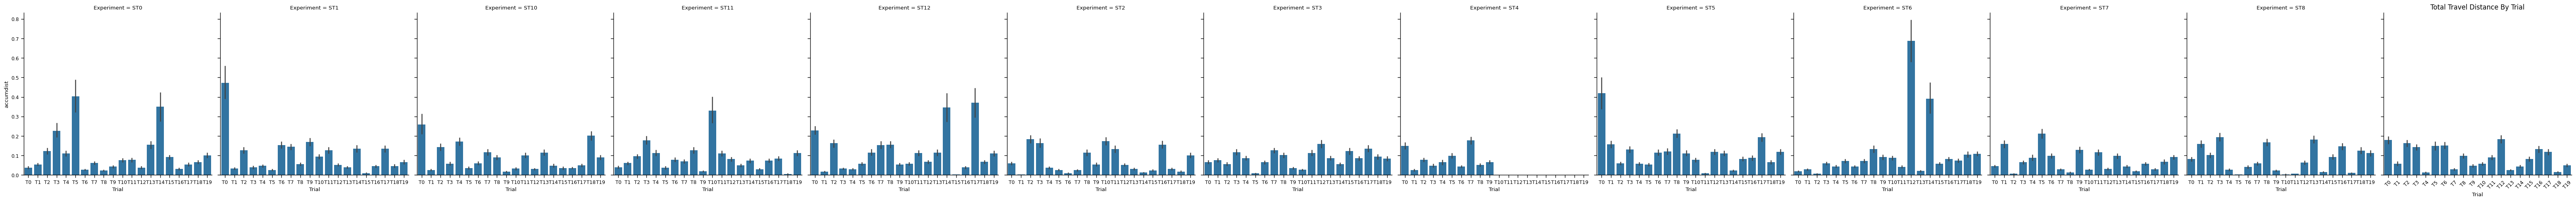

In [49]:
with sns.plotting_context("paper", font_scale=1):# , font_scale=5  , rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= final_df, kind= "bar", col='Experiment',
        x="Trial", y="accumdist", order=['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11',
                                          'T12', 'T13', 'T14', 'T15', 'T16',  'T17' ,'T18' ,'T19',]
                                        
    )#  alpha=.6,
    plt.xticks(rotation=45)

plt.title("Total Travel Distance By Trial")

Text(0.5, 1.0, '')

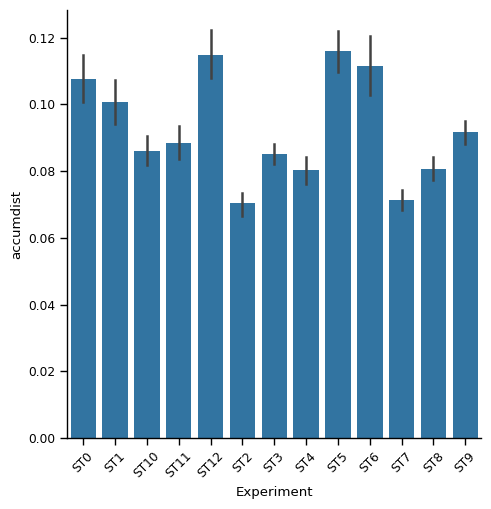

In [68]:
with sns.plotting_context("paper", font_scale=1):# , font_scale=5  , rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= final_df, kind= "bar",
        x="Experiment", y="accumdist", order = ['ST0', 'ST1', 'ST10', 'ST11', 'ST12', 'ST2', 'ST3', 'ST4', 'ST5',
       'ST6', 'ST7', 'ST8', 'ST9']
    )#  alpha=.6,
    plt.xticks(rotation=45)



title = "Total Travel distance By Experiment For GA Experiment  Trials"
plt.title(title)

plt.savefig(f"AntBotFigs/{title}.png")
plt.title("")

Text(0.5, 1.0, '')

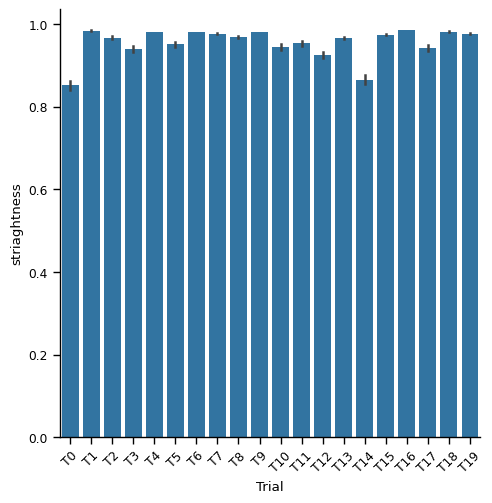

In [69]:
with sns.plotting_context("paper", font_scale=1):# , font_scale=5  , rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= final_df, kind= "bar",
        x="Trial", y="striaghtness",  order=['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11',
                                          'T12', 'T13', 'T14', 'T15', 'T16',  'T17' ,'T18' ,'T19',]
    )#  alpha=.6,
    plt.xticks(rotation=45)


title = "Path Straightness Over Learning trials For GA Trials"
plt.title(title)

plt.savefig(f"AntBotFigs/{title}.png")
plt.title("")

In [61]:
np.unique(final_df['Experiment'])

array(['ST0', 'ST1', 'ST10', 'ST11', 'ST12', 'ST2', 'ST3', 'ST4', 'ST5',
       'ST6', 'ST7', 'ST8', 'ST9'], dtype=object)

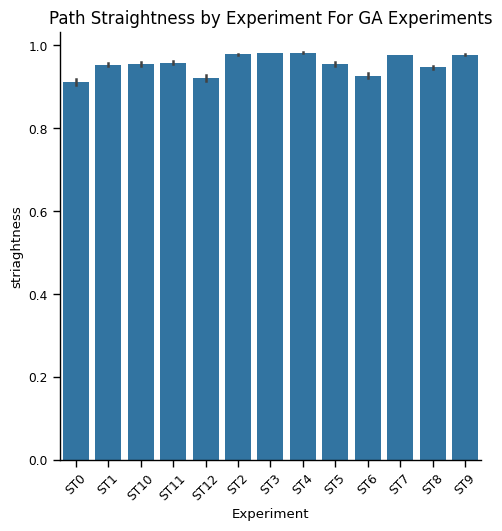

In [70]:
with sns.plotting_context("paper", font_scale=1):# , font_scale=5  , rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= final_df, kind= "bar",
        x="Experiment", y="striaghtness", order = ['ST0', 'ST1', 'ST10', 'ST11', 'ST12', 'ST2', 'ST3', 'ST4', 'ST5',
       'ST6', 'ST7', 'ST8', 'ST9']
    )#  alpha=.6,
    plt.xticks(rotation=45)

title = "Path Straightness by Experiment For GA Experiments"
plt.title(title)

plt.savefig(f"AntBotFigs/{title}.png")


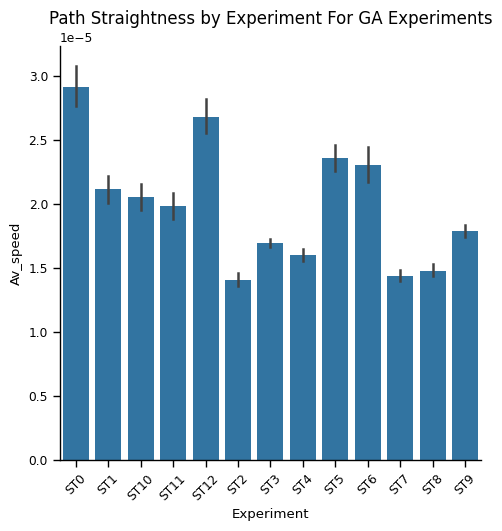

In [71]:
with sns.plotting_context("paper", font_scale=1):# , font_scale=5  , rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= final_df, kind= "bar",
        x="Experiment", y="Av_speed", order = ['ST0', 'ST1', 'ST10', 'ST11', 'ST12', 'ST2', 'ST3', 'ST4', 'ST5',
       'ST6', 'ST7', 'ST8', 'ST9']
    )#  alpha=.6,
    plt.xticks(rotation=45)



title = "Path Straightness by Experiment For GA Experiments"
plt.title(title)

plt.savefig(f"AntBotFigs/{title}.png")

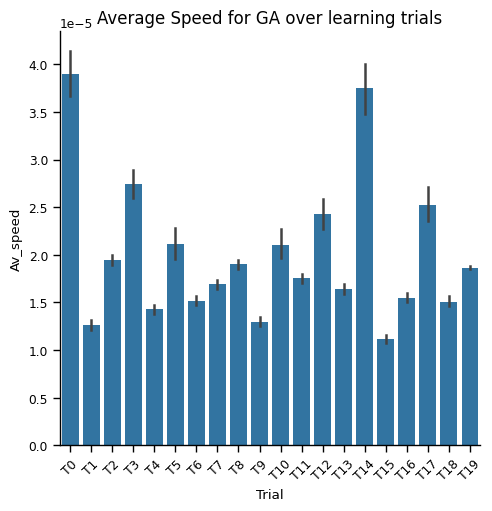

In [72]:
with sns.plotting_context("paper", font_scale=1):# , font_scale=5  , rc={'legend.fontsize': 'large'}):
    g = sns.catplot(
        data= final_df, kind= "bar",
        x="Trial", y="Av_speed",order=['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11',
                                          'T12', 'T13', 'T14', 'T15', 'T16',  'T17' ,'T18' ,'T19']
    )#  alpha=.6,
    plt.xticks(rotation=45)

title = "Average Speed for GA over learning trials"
plt.title(title)

plt.savefig(f"AntBotFigs/{title}.png")
